# Used Car Selling Price Prediction
### A complete regression project using Python and scikit-learn

**Course:** B.Tech CSE (AI & ML), 3rd year - Machine Learning academic project
**Dataset file:** `data/car.csv`
**Target:** `Selling_Price` (in lakhs of INR)

> **How to read this notebook.** Every section has a short explanation, the code, its output and a short interpretation.
> Numbers quoted in the markdown were observed when this notebook was run with `random_state=42` and the cleaning
> decisions explained in Section 7. If you change those settings, re-run the notebook and re-read the interpretations.

## 1. Problem Statement

> *Develop an ML model for car selling price prediction and analysis. The deployed system will provide users with an approximate selling price for their cars based on several features, including fuel type, years of service, showroom price, number of previous owners, kilometers driven, whether the seller is a dealer or an individual, and transmission type.*

## 2. Objectives

1. Inspect the provided dataset without assuming it matches any known Kaggle dataset.
2. Clean the data (including a mixed-vehicle-type issue found during inspection - Section 7) and engineer a car-age feature.
3. Explore the data visually to see which features relate to price.
4. Train and compare four regression models: Linear Regression, Decision Tree, Random Forest, Gradient Boosting.
5. Evaluate with MAE, MSE, RMSE and R² using cross-validation, select a final model, and save it.
6. Build a prediction function and a Streamlit app that use the exact same preprocessing as training.

## 3. Import Libraries

In [1]:
import sys
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Make the project's src/ folder importable (this notebook lives in notebooks/)
PROJECT_ROOT = Path.cwd().resolve().parent
sys.path.append(str(PROJECT_ROOT / "src"))

from preprocessing import (ALL_FEATURES, CATEGORICAL_FEATURES, DATA_PATH,
                           NUMERIC_FEATURES, RANDOM_STATE, TARGET_COLUMN,
                           TEST_SIZE, clean_data, filter_to_cars, inspect_data,
                           load_raw_data, split_data, split_xy)
from evaluate import (PLOTS_DIR, RESULTS_DIR, MODEL_PATH, evaluate_pipeline,
                      plot_actual_vs_predicted, plot_feature_importance,
                      plot_model_comparison, plot_residuals, plot_train_vs_test,
                      regression_metrics)
from train import (CV_FOLDS, build_pipelines, choose_best_model,
                   compare_target_transform, cross_validate_models,
                   fit_and_evaluate, get_importances, save_artifacts, tune_model)
from predict import format_price, load_metadata, predict_price

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 30)
PLOTS_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)


def save_fig(name):
    plt.gcf().savefig(PLOTS_DIR / name, dpi=150, bbox_inches="tight")


print("Libraries imported. Project root:", PROJECT_ROOT.name)

Libraries imported. Project root: used-car-price-prediction


## 4. Load Dataset

In [2]:
raw = load_raw_data()
print("File:", DATA_PATH.name)
print("Shape (rows, columns):", raw.shape)
raw.head()

File: car.csv
Shape (rows, columns): (301, 9)


,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


## 5. Dataset Inspection

In [3]:
info = inspect_data(raw)
print("Number of rows   :", info["shape"][0])
print("Number of columns:", info["shape"][1])
print("Column names     :", info["columns"])
print("Duplicate rows   :", info["duplicate_rows"])
print("Constant columns :", info["constant_columns"] or "none")

Number of rows   : 301
Number of columns: 9
Column names     : ['Car_Name', 'Year', 'Selling_Price', 'Present_Price', 'Kms_Driven', 'Fuel_Type', 'Seller_Type', 'Transmission', 'Owner']
Duplicate rows   : 2
Constant columns : none


In [4]:
summary = pd.DataFrame({
    "dtype": raw.dtypes.astype(str),
    "missing": raw.isna().sum(),
    "unique_values": raw.nunique(),
})
summary

,dtype,missing,unique_values
Car_Name,str,0,98
Year,int64,0,16
Selling_Price,float64,0,156
Present_Price,float64,0,147
Kms_Driven,int64,0,206
Fuel_Type,str,0,3
Seller_Type,str,0,2
Transmission,str,0,2
Owner,int64,0,3


In [5]:
raw.describe().T.round(3)

,count,mean,std,min,25%,50%,75%,max
Year,301.0,2013.628,2.892,2003.00,2012.0,2014.0,2016.0,2018.0
Selling_Price,301.0,4.661,5.083,0.10,0.9,3.6,6.0,35.0
Present_Price,301.0,7.628,8.644,0.32,1.2,6.4,9.9,92.6
Kms_Driven,301.0,36947.206,38886.884,500.00,15000.0,32000.0,48767.0,500000.0
Owner,301.0,0.043,0.248,0.00,0.0,0.0,0.0,3.0


In [6]:
for col in ["Fuel_Type", "Seller_Type", "Transmission", "Owner"]:
    print(f"\n{col} value counts:")
    print(raw[col].value_counts())


Fuel_Type value counts:
Fuel_Type
Petrol    239
Diesel     60
CNG         2
Name: count, dtype: int64

Seller_Type value counts:
Seller_Type
Dealer        195
Individual    106
Name: count, dtype: int64

Transmission value counts:
Transmission
Manual       261
Automatic     40
Name: count, dtype: int64

Owner value counts:
Owner
0    290
1     10
3      1
Name: count, dtype: int64


**Observations.**

* **301 rows, 9 columns, no missing values anywhere.** `Car_Name` is text, `Fuel_Type`/`Seller_Type`/`Transmission` are low-cardinality categories, and the rest are numeric.
* **2 exact duplicate rows** exist (checked below).
* `Car_Name` has 98 unique values across 301 rows - too many to use directly as a model input.
* `Selling_Price` (the price the car sold for) is the only column that matches "selling price" in the problem statement, has no missing values, and is numeric and continuous. **It is the target.**

### 5.1 A critical finding: the file mixes cars with two-wheelers

In [7]:
sample_names = sorted(raw["Car_Name"].unique())
print(sample_names)

['800', 'Activa 3g', 'Activa 4g', 'Bajaj  ct 100', 'Bajaj Avenger 150', 'Bajaj Avenger 150 street', 'Bajaj Avenger 220', 'Bajaj Avenger 220 dtsi', 'Bajaj Avenger Street 220', 'Bajaj Discover 100', 'Bajaj Discover 125', 'Bajaj Dominar 400', 'Bajaj Pulsar  NS 200', 'Bajaj Pulsar 135 LS', 'Bajaj Pulsar 150', 'Bajaj Pulsar 220 F', 'Bajaj Pulsar NS 200', 'Bajaj Pulsar RS200', 'Hero  CBZ Xtreme', 'Hero  Ignitor Disc', 'Hero Extreme', 'Hero Glamour', 'Hero Honda CBZ extreme', 'Hero Honda Passion Pro', 'Hero Hunk', 'Hero Passion Pro', 'Hero Passion X pro', 'Hero Splender Plus', 'Hero Splender iSmart', 'Hero Super Splendor', 'Honda Activa 125', 'Honda Activa 4G', 'Honda CB Hornet 160R', 'Honda CB Shine', 'Honda CB Trigger', 'Honda CB Unicorn', 'Honda CB twister', 'Honda CBR 150', 'Honda Dream Yuga ', 'Honda Karizma', 'Hyosung GT250R', 'KTM 390 Duke ', 'KTM RC200', 'KTM RC390', 'Mahindra Mojo XT300', 'Royal Enfield Bullet 350', 'Royal Enfield Classic 350', 'Royal Enfield Classic 500', 'Royal Enf

Reading through the `Car_Name` values shows many motorcycle and scooter brands: **Bajaj, Hero, Honda Activa/CB/CBR/Karizma, Hyosung, KTM, Mahindra Mojo, Royal Enfield, Suzuki Access, TVS, UM, Yamaha.** These are two-wheelers, not cars. This is not a one-off labelling slip - it is a distinct, internally consistent group.

In [8]:
cars_only, two_wheelers = filter_to_cars(raw)
print(f"Two-wheeler rows: {len(two_wheelers)}  |  Car rows: {len(cars_only)}  |  Total: {len(raw)}")

compare = pd.DataFrame({
    "Two-wheelers": two_wheelers["Selling_Price"].describe(),
    "Cars": cars_only["Selling_Price"].describe(),
}).round(2)
compare

Two-wheeler rows: 101  |  Car rows: 200  |  Total: 301


,Two-wheelers,Cars
count,101.00,200.00
mean,0.64,6.69
std,0.39,5.15
min,0.10,0.35
25%,0.38,3.64
50%,0.50,5.25
75%,0.90,7.56
max,1.75,35.00


In [9]:
print("Two-wheeler Fuel_Type:", two_wheelers["Fuel_Type"].unique())
print("Two-wheeler Present_Price range:", two_wheelers["Present_Price"].min(),
      "-", two_wheelers["Present_Price"].max())
print("Car Present_Price range:", cars_only["Present_Price"].min(),
      "-", cars_only["Present_Price"].max())

Two-wheeler Fuel_Type: <ArrowStringArray>
['Petrol']
Length: 1, dtype: str
Two-wheeler Present_Price range: 0.32 - 3.45
Car Present_Price range: 2.28 - 92.6


**Decision.** The two groups have non-overlapping price scales (two-wheelers top out at ₹1.75 lakh; the cheapest car is ₹0.35 lakh but most cost several lakhs) and two-wheelers are 100% Petrol. Since the assignment specifically asks for **car** price prediction, mixing the two would badly distort the target distribution and every relationship in the data. **The 101 two-wheeler rows are excluded from modelling** (saved separately to `outputs/results/excluded_two_wheelers.csv` for transparency, not silently discarded). This leaves **200 car rows**.

## 6. Data Cleaning

Two more things need handling before modelling: duplicate rows, and turning `Year` into a more directly useful `Car_Age`.

In [10]:
print("Duplicate rows among the 200 cars:", cars_only.duplicated().sum())
cars_only[cars_only.duplicated(keep=False)]

Duplicate rows among the 200 cars: 2


,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
15,ertiga,2016,7.75,10.79,43000,Diesel,Dealer,Manual,0
17,ertiga,2016,7.75,10.79,43000,Diesel,Dealer,Manual,0
51,fortuner,2015,23.00,30.61,40000,Diesel,Dealer,Automatic,0
93,fortuner,2015,23.00,30.61,40000,Diesel,Dealer,Automatic,0


Two pairs of rows are identical in every column (an `ertiga` and a `fortuner`, each appearing twice). These look like accidental double-entries rather than two different real cars, so the duplicates are removed, leaving **198 rows**.

In [11]:
cars, two_wheelers_saved, reference_year = clean_data(raw)
print("Final cleaned shape:", cars.shape)
print("Car_Age reference year (= max Year in the data):", reference_year)
cars[["Car_Name", "Year", "Car_Age"]].head()

Final cleaned shape: (198, 10)
Car_Age reference year (= max Year in the data): 2018


,Car_Name,Year,Car_Age
0,ritz,2014,4
1,sx4,2013,5
2,ciaz,2017,1
3,wagon r,2011,7
4,swift,2014,4


**Car_Age** is engineered as `reference_year - Year`, where `reference_year` is the maximum `Year` found in the dataset (2018) rather than an assumed "today" - this keeps the feature grounded in the data actually supplied. The problem statement asks for "years of service", which `Car_Age` represents directly and more intuitively than the raw manufacture year.

### 6.1 Other data-quality checks

In [12]:
print("Rows where Selling_Price > Present_Price (a used car selling for more than a new one - would be suspicious):",
      (cars["Selling_Price"] > cars["Present_Price"]).sum())
print("Constant columns:", [c for c in cars.columns if cars[c].nunique() <= 1])
print("Any missing values left:", cars.isna().sum().sum())

Rows where Selling_Price > Present_Price (a used car selling for more than a new one - would be suspicious): 0
Constant columns: []
Any missing values left: 0


No car sells for more than its current showroom price, there are no constant columns, and there are no missing values. No further cleaning is required.

## 7. Exploratory Data Analysis

All EDA below uses the cleaned 198-row car dataset.

### 7.1 Distribution of the target

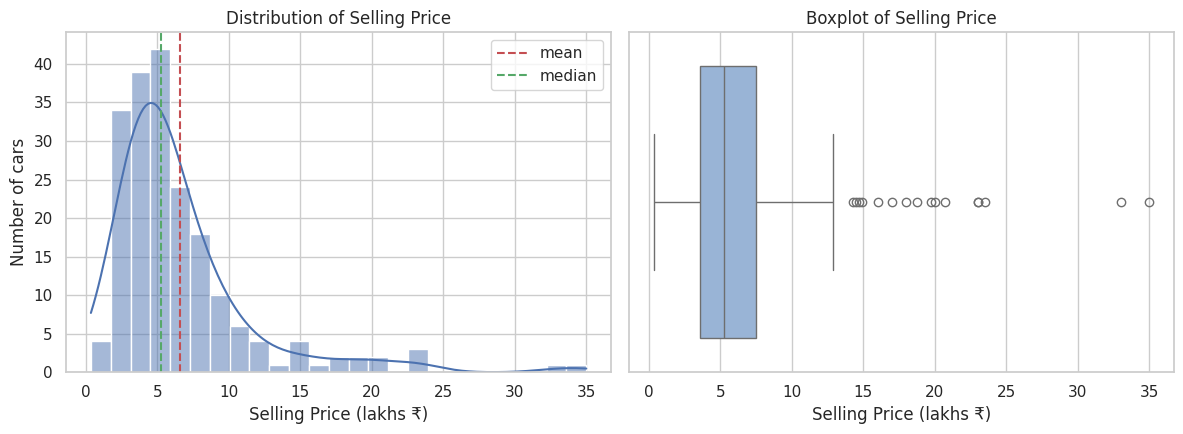

Skewness: 2.698


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.histplot(cars["Selling_Price"], bins=25, kde=True, ax=axes[0], color="#4C72B0")
axes[0].axvline(cars["Selling_Price"].mean(), color="r", linestyle="--", label="mean")
axes[0].axvline(cars["Selling_Price"].median(), color="g", linestyle="--", label="median")
axes[0].set_title("Distribution of Selling Price")
axes[0].set_xlabel("Selling Price (lakhs ₹)")
axes[0].set_ylabel("Number of cars")
axes[0].legend()

sns.boxplot(x=cars["Selling_Price"], ax=axes[1], color="#8FB3E0")
axes[1].set_title("Boxplot of Selling Price")
axes[1].set_xlabel("Selling Price (lakhs ₹)")
plt.tight_layout()
save_fig("01_target_distribution.png")
plt.show()

print("Skewness:", round(cars["Selling_Price"].skew(), 3))

**Interpretation.** Most cars sell for ₹3.6-7.5 lakh (interquartile range), with a mean of ₹6.6 lakh pulled above the median (₹5.25 lakh) by a handful of expensive cars. The distribution is **right-skewed (skewness 2.70)**: a few premium cars (Land Cruiser ₹35L, Fortuner up to ₹33L) create a long right tail. This skew is revisited in Feature Engineering (Section 9).

### 7.2 Numerical feature distributions and boxplots

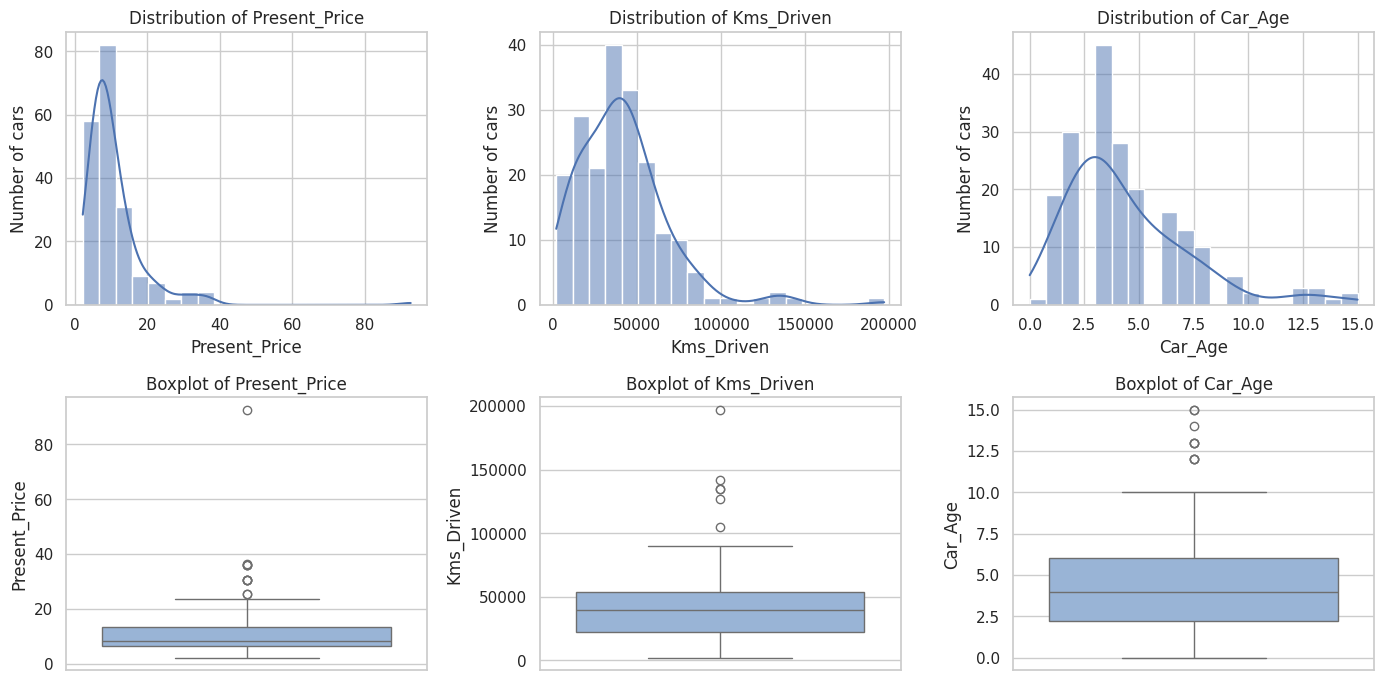

In [14]:
num_cols = ["Present_Price", "Kms_Driven", "Car_Age"]
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for i, col in enumerate(num_cols):
    sns.histplot(cars[col], bins=20, kde=True, ax=axes[0, i], color="#4C72B0")
    axes[0, i].set_title(f"Distribution of {col}")
    axes[0, i].set_xlabel(col)
    axes[0, i].set_ylabel("Number of cars")

    sns.boxplot(y=cars[col], ax=axes[1, i], color="#8FB3E0")
    axes[1, i].set_title(f"Boxplot of {col}")
    axes[1, i].set_ylabel(col)
plt.tight_layout()
save_fig("02_numeric_distributions.png")
plt.show()

**Interpretation.** `Present_Price` is heavily right-skewed (a handful of premium cars, up to ₹92.6L). `Kms_Driven` is also right-skewed, with a few very high-mileage older cars. `Car_Age` ranges from new (0 years) to 15 years, roughly bell-shaped with a peak around 3-6 years.

### 7.3 Correlation heatmap

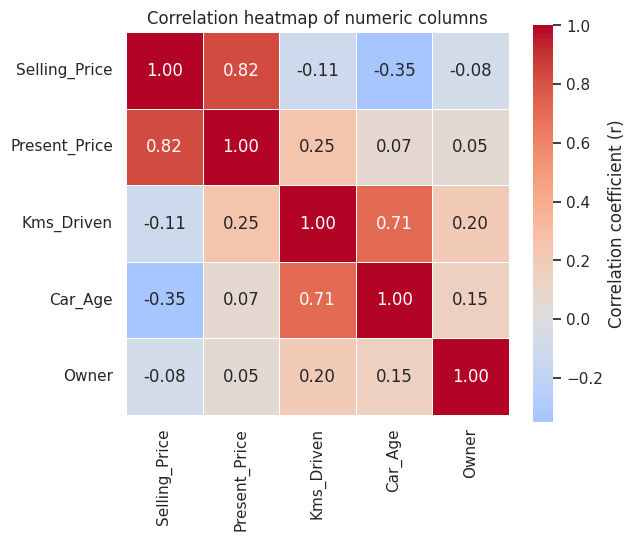

In [15]:
numeric_for_corr = cars[["Selling_Price", "Present_Price", "Kms_Driven", "Car_Age", "Owner"]]
corr = numeric_for_corr.corr()

plt.figure(figsize=(6.5, 5.5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True,
            linewidths=0.5, cbar_kws={"label": "Correlation coefficient (r)"})
plt.title("Correlation heatmap of numeric columns")
plt.tight_layout()
save_fig("03_correlation_heatmap.png")
plt.show()

**Interpretation.** `Present_Price` correlates very strongly with `Selling_Price` (**r = 0.82**) - unsurprising, since a car's resale value is naturally tied to what it costs new. `Car_Age` has a moderate negative correlation (**-0.35**): older cars sell for less. `Kms_Driven` (-0.11) and `Owner` (-0.09) have weak direct correlations with price on their own.

### 7.4 Selling Price vs Kilometers Driven

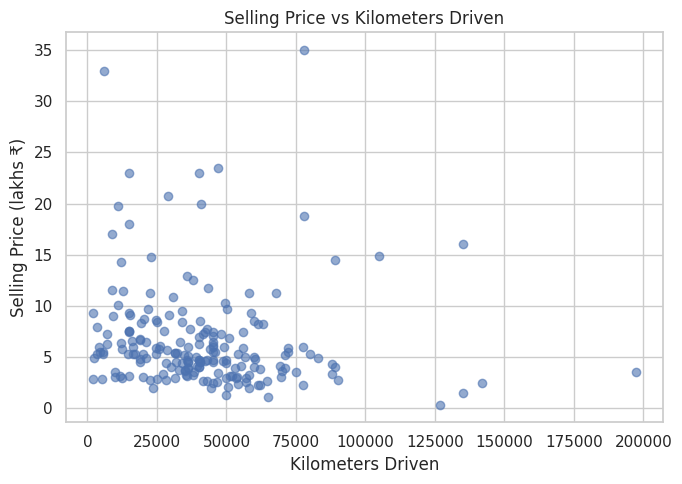

In [16]:
plt.figure(figsize=(7, 5))
plt.scatter(cars["Kms_Driven"], cars["Selling_Price"], alpha=0.6, color="#4C72B0")
plt.title("Selling Price vs Kilometers Driven")
plt.xlabel("Kilometers Driven")
plt.ylabel("Selling Price (lakhs ₹)")
plt.tight_layout()
save_fig("04_price_vs_kms.png")
plt.show()

**Interpretation.** There is no strong linear trend - most cars cluster under 100,000 km regardless of price, and a few high-mileage cars (100,000-200,000 km) are all low-priced. Kilometers driven alone is a weak predictor here, likely because it is entangled with car age and the car's original price bracket.

### 7.5 Selling Price vs Years of Service (Car Age)

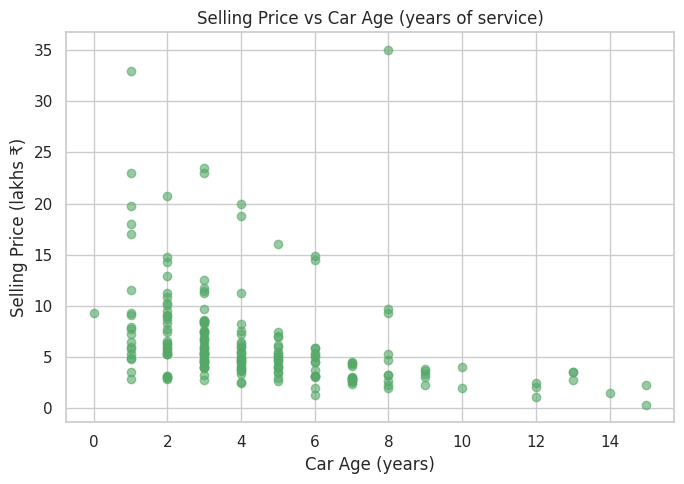

In [17]:
plt.figure(figsize=(7, 5))
plt.scatter(cars["Car_Age"], cars["Selling_Price"], alpha=0.6, color="#55A868")
plt.title("Selling Price vs Car Age (years of service)")
plt.xlabel("Car Age (years)")
plt.ylabel("Selling Price (lakhs ₹)")
plt.tight_layout()
save_fig("05_price_vs_age.png")
plt.show()

**Interpretation.** Prices generally fall as age increases, but scatter is wide because a car's starting price bracket matters too (an old luxury car can still be pricier than a new budget car). The relationship becomes clearer when looking at *depreciation* directly, below.

### 7.6 Selling Price vs Present (Showroom) Price

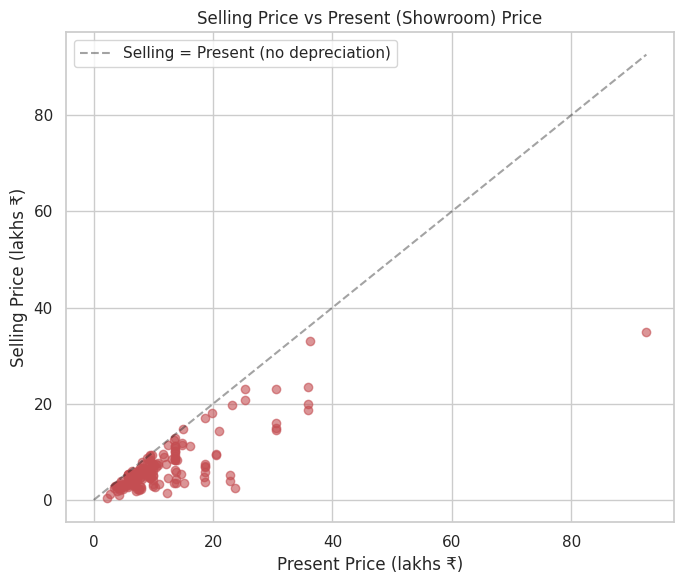

In [18]:
plt.figure(figsize=(7, 6))
plt.scatter(cars["Present_Price"], cars["Selling_Price"], alpha=0.6, color="#C44E52")
low, high = 0, max(cars["Present_Price"].max(), cars["Selling_Price"].max())
plt.plot([low, high], [low, high], "k--", alpha=0.4, label="Selling = Present (no depreciation)")
plt.title("Selling Price vs Present (Showroom) Price")
plt.xlabel("Present Price (lakhs ₹)")
plt.ylabel("Selling Price (lakhs ₹)")
plt.legend()
plt.tight_layout()
save_fig("06_price_vs_present_price.png")
plt.show()

**Interpretation.** This is the clearest relationship in the dataset (r = 0.82). Every point sits below the "no depreciation" line, as expected for a used car. The vertical spread at any given showroom price reflects age, mileage and other factors.

### 7.7 Depreciation: Selling Price as a fraction of Present Price, by age

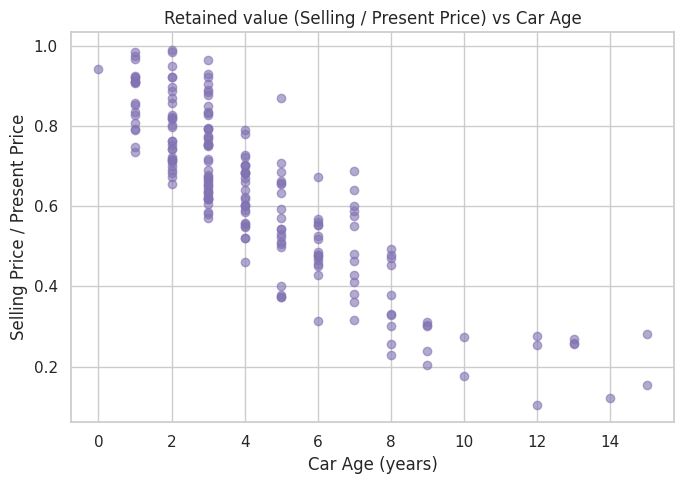

Correlation between price ratio and Car_Age: -0.86


In [19]:
cars_ratio = cars.assign(price_ratio=cars["Selling_Price"] / cars["Present_Price"])

plt.figure(figsize=(7, 5))
plt.scatter(cars_ratio["Car_Age"], cars_ratio["price_ratio"], alpha=0.6, color="#8172B2")
plt.title("Retained value (Selling / Present Price) vs Car Age")
plt.xlabel("Car Age (years)")
plt.ylabel("Selling Price / Present Price")
plt.tight_layout()
save_fig("07_depreciation_vs_age.png")
plt.show()

print("Correlation between price ratio and Car_Age:", round(cars_ratio["price_ratio"].corr(cars_ratio["Car_Age"]), 3))

**Interpretation.** This confirms depreciation directly: on average a car retains 63% of its current showroom price when resold, but this ratio falls steadily with age (**r = -0.86** between the ratio and age) - much stronger than the -0.35 seen between raw price and age. Age matters most through how much of a car's value it has used up, not as an isolated number.

### 7.8 Selling Price by Fuel Type

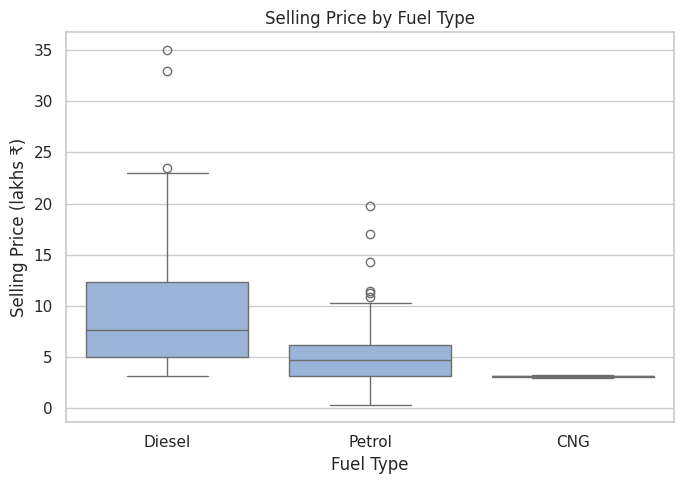

,mean,median,count
Fuel_Type,,,
CNG,3.10,3.1,2
Diesel,10.10,7.6,58
Petrol,5.18,4.7,138


In [20]:
plt.figure(figsize=(7, 5))
order = cars.groupby("Fuel_Type")["Selling_Price"].median().sort_values(ascending=False).index
sns.boxplot(data=cars, x="Fuel_Type", y="Selling_Price", order=order, color="#8FB3E0")
plt.title("Selling Price by Fuel Type")
plt.xlabel("Fuel Type")
plt.ylabel("Selling Price (lakhs ₹)")
plt.tight_layout()
save_fig("08_price_by_fuel.png")
plt.show()

cars.groupby("Fuel_Type")["Selling_Price"].agg(["mean", "median", "count"]).round(2)

**Interpretation.** Diesel cars sell for noticeably more (mean ₹10.10L, 58 cars) than Petrol cars (mean ₹5.18L, 138 cars) in this dataset - diesel is often associated with larger, higher-end vehicles in the Indian market. **Only 2 CNG cars** are present, so any conclusion about CNG pricing is not statistically reliable.

### 7.9 Selling Price by Transmission Type

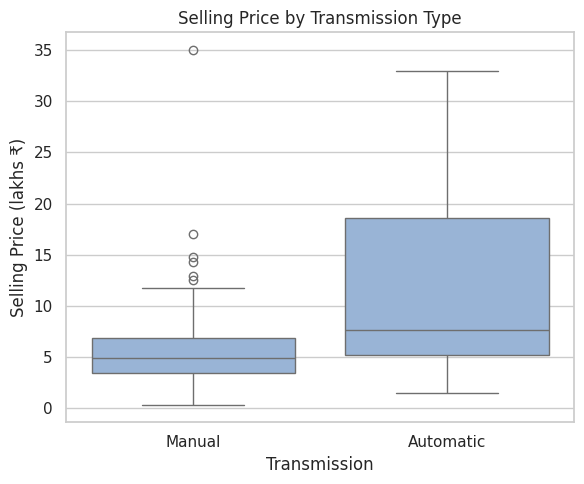

,mean,median,count
Transmission,,,
Automatic,11.69,7.62,30
Manual,5.70,4.93,168


In [21]:
plt.figure(figsize=(6, 5))
sns.boxplot(data=cars, x="Transmission", y="Selling_Price", color="#8FB3E0")
plt.title("Selling Price by Transmission Type")
plt.xlabel("Transmission")
plt.ylabel("Selling Price (lakhs ₹)")
plt.tight_layout()
save_fig("09_price_by_transmission.png")
plt.show()

cars.groupby("Transmission")["Selling_Price"].agg(["mean", "median", "count"]).round(2)

**Interpretation.** Automatic cars sell for much more on average (₹11.69L, 30 cars) than Manual cars (₹5.70L, 168 cars). This likely reflects that automatic transmission is more common in premium car segments rather than transmission type itself adding value.

### 7.10 Selling Price by Seller Type

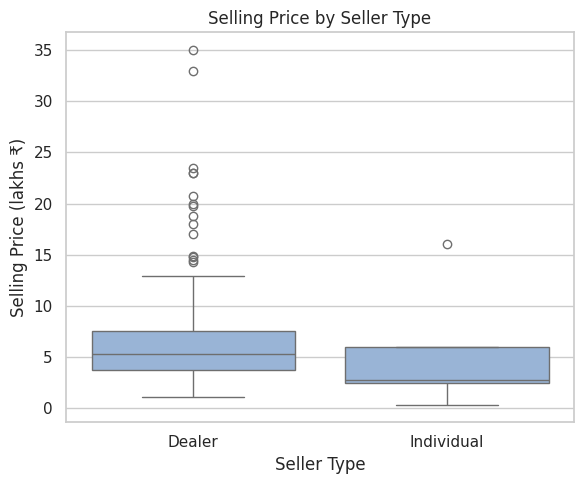

,mean,median,count
Seller_Type,,,
Dealer,6.63,5.25,193
Individual,5.52,2.75,5


In [22]:
plt.figure(figsize=(6, 5))
sns.boxplot(data=cars, x="Seller_Type", y="Selling_Price", color="#8FB3E0")
plt.title("Selling Price by Seller Type")
plt.xlabel("Seller Type")
plt.ylabel("Selling Price (lakhs ₹)")
plt.tight_layout()
save_fig("10_price_by_seller.png")
plt.show()

cars.groupby("Seller_Type")["Selling_Price"].agg(["mean", "median", "count"]).round(2)

**Interpretation.** Dealer-sold cars average ₹6.63L against ₹5.52L for individual sellers, but **only 5 of 198 cars** are sold by individuals, so this difference should be read cautiously rather than treated as a firm pattern.

### 7.11 Selling Price by Number of Previous Owners

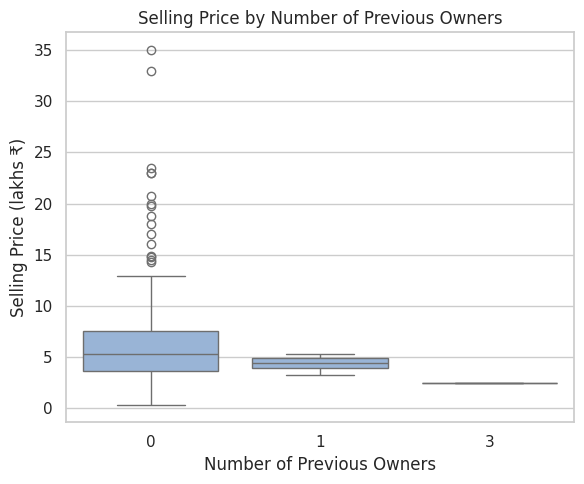

,mean,median,count
Owner,,,
0,6.67,5.25,193
1,4.34,4.42,4
3,2.50,2.50,1


In [23]:
plt.figure(figsize=(6, 5))
sns.boxplot(data=cars, x="Owner", y="Selling_Price", color="#8FB3E0")
plt.title("Selling Price by Number of Previous Owners")
plt.xlabel("Number of Previous Owners")
plt.ylabel("Selling Price (lakhs ₹)")
plt.tight_layout()
save_fig("11_price_by_owner.png")
plt.show()

cars.groupby("Owner")["Selling_Price"].agg(["mean", "median", "count"]).round(2)

**Interpretation.** Price falls as the number of previous owners rises (0 owners: ₹6.67L average; 1 owner: ₹4.34L; 3 owners: a single ₹2.50L car), matching intuition. With only 4 one-owner and 1 three-owner cars, this pattern is suggestive rather than statistically strong.

Correlation values are associations only; none of the patterns above prove that changing one factor (e.g. fuel type) *causes* a price change - other factors (car segment, brand) are entangled with them.

## 8. Feature Engineering

**Car_Age** (Section 6) is the main engineered feature, replacing the raw `Year` with a directly interpretable "years of service" figure requested by the problem statement. `Year` itself is dropped afterwards to avoid redundancy.

**Car_Name** is *not* used as a model input: with 37 unique names across only 198 rows, one-hot encoding it would create more columns than there is data to support reliably, and the problem statement's feature list does not mention car model as an input. It is kept only for readability in the EDA above.

**Interaction features** were considered but not added: with only 198 rows and 7 features, adding interaction terms risks overfitting without a clear justification from the EDA above, so the project keeps the feature set simple as instructed.

### 8.1 Should the skewed target be log-transformed?

`Selling_Price` is right-skewed (skewness 2.70, Section 7.1). A common remedy is to model `log(1 + price)` instead and convert predictions back with `exp(x) - 1`. This is tested properly below with cross-validation, rather than assumed.

In [24]:
transform_table = compare_target_transform(*split_data(cars)[::2])  # X_train, y_train
transform_table.round(3)

,CV_RMSE_raw_target,CV_RMSE_log_target
Linear Regression,1.866,1.649
Decision Tree,1.841,1.501
Random Forest,1.239,1.221
Gradient Boosting,1.158,1.173


**Interpretation.** The log transform noticeably helps the weaker models (Linear Regression: 1.87 → 1.65; Decision Tree: 1.84 → 1.50) by reducing the influence of the few expensive cars. For **Random Forest it is roughly neutral** (1.239 vs 1.221), and for **Gradient Boosting - the strongest model - the raw target is very slightly better** (1.158 vs 1.173). Since Gradient Boosting is expected to be the leading candidate (confirmed in Section 12), **the final model uses the raw target**, and this decision is based on the measured numbers above rather than assumed. The comparison itself remains valuable: it shows that log-transforming would have been the right call had a linear model been selected.

## 9. Feature / Target Separation

In [25]:
X, y = split_xy(cars)
print("Numeric features    :", NUMERIC_FEATURES)
print("Categorical features:", CATEGORICAL_FEATURES)
print("Target              :", TARGET_COLUMN, "(lakhs ₹)")
print("X shape:", X.shape, " y shape:", y.shape)
X.head()

Numeric features    : ['Present_Price', 'Kms_Driven', 'Car_Age', 'Owner']
Categorical features: ['Fuel_Type', 'Seller_Type', 'Transmission']
Target              : Selling_Price (lakhs ₹)
X shape: (198, 7)  y shape: (198,)


,Present_Price,Kms_Driven,Car_Age,Owner,Fuel_Type,Seller_Type,Transmission
0,5.59,27000,4,0,Petrol,Dealer,Manual
1,9.54,43000,5,0,Diesel,Dealer,Manual
2,9.85,6900,1,0,Petrol,Dealer,Manual
3,4.15,5200,7,0,Petrol,Dealer,Manual
4,6.87,42450,4,0,Diesel,Dealer,Manual


## 10. Preprocessing

**Categorical variables** (`Fuel_Type`, `Seller_Type`, `Transmission`) each have only 2-3 possible values, so **One-Hot Encoding** is an appropriate, simple choice - it does not create excessive columns and does not impose a false ordering the way label encoding would. `handle_unknown="ignore"` protects the pipeline against an unseen category at prediction time.

**Numerical scaling.** Features are on very different scales (`Present_Price` in single/double digits, `Kms_Driven` in the tens of thousands). Linear Regression is affected by this; the tree-based models (Decision Tree, Random Forest, Gradient Boosting) are not, because they only compare a feature against thresholds.

**No missing-value imputation is needed** - the dataset has zero missing values (confirmed in Section 5).

**Avoiding data leakage.** All preprocessing (scaling, encoding categories) is placed inside a single scikit-learn `Pipeline` together with the model, so it is fit on the training data only and merely applied to the test data.

In [26]:
from preprocessing import build_preprocessor
print(build_preprocessor(scale=True))

ColumnTransformer(transformers=[('numeric',
                                 Pipeline(steps=[('scale', StandardScaler())]),
                                 ['Present_Price', 'Kms_Driven', 'Car_Age',
                                  'Owner']),
                                ('categorical',
                                 Pipeline(steps=[('onehot',
                                                  OneHotEncoder(drop='if_binary',
                                                                handle_unknown='ignore'))]),
                                 ['Fuel_Type', 'Seller_Type', 'Transmission'])],
                  verbose_feature_names_out=False)


## 11. Train-Test Split

An 80/20 split is used, holding back 20% of cars (unseen during training) to give an honest measure of performance on new cars. `random_state=42` makes the split reproducible.

In [27]:
X_train, X_test, y_train, y_test = split_data(cars)
print(f"Training set: {X_train.shape[0]} cars | Test set: {X_test.shape[0]} cars "
      f"({TEST_SIZE:.0%} test, random_state={RANDOM_STATE})")
print("\nTarget statistics in each split:")
pd.DataFrame({"train": y_train.describe(), "test": y_test.describe()}).round(2)

Training set: 158 cars | Test set: 40 cars (20% test, random_state=42)

Target statistics in each split:


,train,test
count,158.00,40.00
mean,6.67,6.36
std,4.83,5.88
min,0.35,1.50
25%,3.76,3.41
50%,5.25,4.62
75%,8.16,6.60
max,33.00,35.00


Training and test targets have broadly similar means (6.67 vs 6.36) though the test set's standard deviation (5.88) is a little higher than training's (4.83) - a reminder that with only 198 rows a single split carries some randomness, which is why cross-validation (next section) is used for model selection.

## 12. Model Training

Four regression models are compared, as required by the assignment:

| Model | Idea | Strength | Limitation |
|---|---|---|---|
| **Linear Regression** | Fits `price = b0 + b1·x1 + ...` by least squares | Simple, interpretable | Cannot capture non-linear effects |
| **Decision Tree** (depth 5) | A chain of yes/no threshold questions | Captures non-linearity, no scaling needed | A single tree overfits easily |
| **Random Forest** (200 trees) | Averages many trees on random samples | More stable than one tree | Slower, harder to interpret |
| **Gradient Boosting** | Trees added sequentially, each fixing earlier errors | Often most accurate on tabular data | More settings to tune, can overfit |

Models are compared with **5-fold cross-validation on the training set only**, so the test set cannot influence which model is chosen.

In [28]:
pipelines = build_pipelines()
cv_table = cross_validate_models(pipelines, X_train, y_train)
cv_table.round(3)

,CV_RMSE_mean,CV_RMSE_std,CV_MAE_mean,CV_R2_mean,CV_R2_std
Linear Regression,1.866,0.513,1.312,0.829,0.055
Decision Tree,1.841,0.370,1.165,0.827,0.064
Random Forest,1.239,0.457,0.806,0.929,0.015
Gradient Boosting,1.158,0.491,0.770,0.938,0.021


In [29]:
results = fit_and_evaluate(pipelines, X_train, y_train, X_test, y_test)
results = results.join(cv_table[["CV_RMSE_mean", "CV_R2_mean"]])
results.round(3)

,Train_MAE,Train_MSE,Train_RMSE,Train_R2,Test_MAE,Test_MSE,Test_RMSE,Test_R2,CV_RMSE_mean,CV_R2_mean
Linear Regression,1.159,2.679,1.637,0.884,1.395,6.785,2.605,0.799,1.866,0.829
Decision Tree,0.578,0.673,0.820,0.971,1.475,12.354,3.515,0.634,1.841,0.827
Random Forest,0.291,0.207,0.455,0.991,1.133,7.186,2.681,0.787,1.239,0.929
Gradient Boosting,0.228,0.081,0.284,0.997,1.192,8.805,2.967,0.739,1.158,0.938


**Interpretation.** Random Forest and Gradient Boosting reach a very high training R² (0.99+) but noticeably lower test R² (0.79, 0.74), a sign of some **overfitting** - expected with only 158 training rows and models this flexible. Linear Regression's training and test R² are closer together (0.88 vs 0.80), typical of a simpler model.

## 13. Model Evaluation

* **MAE**: average absolute error, in lakhs ₹.
* **MSE**: average squared error (penalises big misses heavily).
* **RMSE**: square root of MSE, in the same unit as price.
* **R²**: share of price variation explained (1 = perfect).

No model is chosen by R² alone - cross-validated RMSE, the train/test gap, and the plots below are all considered together.

In [30]:
test_table = results[["Test_MAE", "Test_MSE", "Test_RMSE", "Test_R2"]].copy()
test_table.columns = ["MAE", "MSE", "RMSE", "R²"]
test_table.index.name = "Model"
test_table.round(3)

,MAE,MSE,RMSE,R²
Model,,,,
Linear Regression,1.395,6.785,2.605,0.799
Decision Tree,1.475,12.354,3.515,0.634
Random Forest,1.133,7.186,2.681,0.787
Gradient Boosting,1.192,8.805,2.967,0.739


## 14. Model Comparison

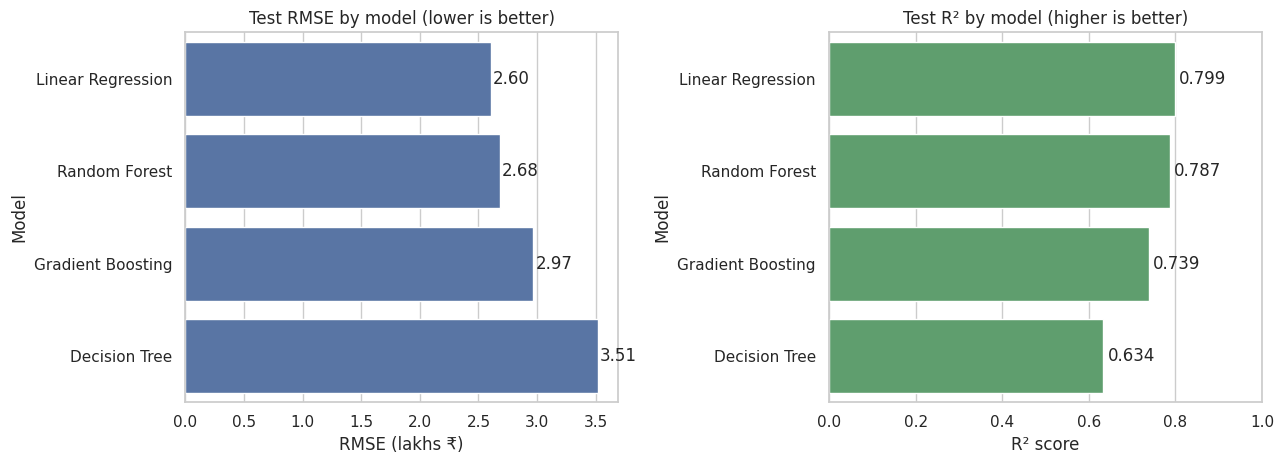

In [31]:
plot_model_comparison(results, filename=None)
plt.show()

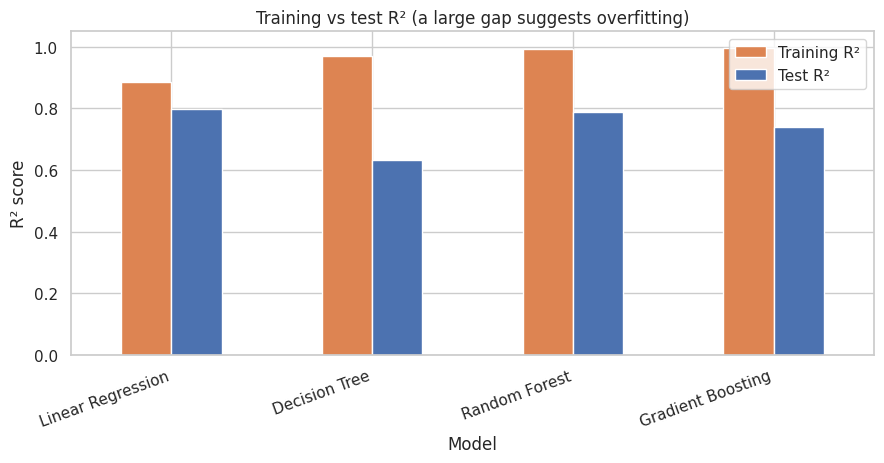

In [32]:
plot_train_vs_test(results, filename=None)
plt.show()

**Cross-validated ranking (training data, most reliable for model choice):** Gradient Boosting (RMSE 1.16) < Random Forest (1.24) < Decision Tree (1.84) ≈ Linear Regression (1.87).

**Test-set ranking is a little different:** Linear Regression's test RMSE (2.61) looks competitive with the ensembles (Gradient Boosting 2.97, Random Forest 2.68) - this is investigated in Section 16, and turns out to be driven by one very expensive, rarely-seen car landing in the small 40-row test set, not by Linear Regression genuinely generalising better. Cross-validation, not the single test split, is used to choose the model.

## 15. Final Model Selection

The model with the lowest cross-validated RMSE is selected, then tuned with a small grid search (also cross-validated on training data only). The test set is used exactly once, after the choice is made.

In [33]:
best_name = choose_best_model(cv_table)
baseline_cv_rmse = cv_table.loc[best_name, "CV_RMSE_mean"]
print("Model with the lowest cross-validated RMSE:", best_name)

search = tune_model(best_name, build_pipelines()[best_name], X_train, y_train)
tuned_cv_rmse = -search.best_score_
print(f"CV RMSE  default settings: {baseline_cv_rmse:.3f}")
print(f"CV RMSE  after tuning    : {tuned_cv_rmse:.3f}")
print("Best parameters:", search.best_params_)

tuned = tuned_cv_rmse < baseline_cv_rmse
final_pipeline = search.best_estimator_ if tuned else pipelines[best_name]
best_params = search.best_params_ if tuned else {}

Model with the lowest cross-validated RMSE: Gradient Boosting


CV RMSE  default settings: 1.158
CV RMSE  after tuning    : 1.136
Best parameters: {'model__learning_rate': 0.05, 'model__max_depth': 3, 'model__n_estimators': 400}


In [34]:
train_pred = final_pipeline.predict(X_train)
test_pred = final_pipeline.predict(X_test)
train_metrics = regression_metrics(y_train, train_pred)
test_metrics = regression_metrics(y_test, test_pred)

final_report = pd.DataFrame({"Training": train_metrics, "Test": test_metrics}).T
final_report.columns = ["MAE", "MSE", "RMSE", "R²"]
print("Final model:", best_name, "(tuned)" if tuned else "(default settings)")
final_report.round(4)

Final model: Gradient Boosting (tuned)


,MAE,MSE,RMSE,R²
Training,0.1204,0.0259,0.1611,0.9989
Test,1.1934,7.7836,2.7899,0.7694


**Why Gradient Boosting was selected.** It had the lowest cross-validated RMSE (1.16) and MAE, and the highest cross-validated R² (0.94) of all four models - a clear margin over Random Forest (RMSE 1.24) and a larger one over the simpler models. Tuning improved the cross-validated RMSE slightly further, from 1.158 to 1.136.

**An honest look at the test-set R².** The tuned model's test R² (0.769) is noticeably lower than its cross-validated R² (0.938). Section 16 shows this gap is dominated by a single high-value car in the small test set, not a general failure of the model.

In [35]:
if tuned:
    tuned_row = evaluate_pipeline(final_pipeline, X_train, y_train, X_test, y_test)
    tuned_row["CV_RMSE_mean"] = tuned_cv_rmse
    results.loc[f"{best_name} (tuned)"] = pd.Series(tuned_row)
results.to_csv(RESULTS_DIR / "model_comparison.csv")
cv_table.to_csv(RESULTS_DIR / "cv_results.csv")
results[["Test_MAE", "Test_MSE", "Test_RMSE", "Test_R2"]].round(3)

,Test_MAE,Test_MSE,Test_RMSE,Test_R2
Linear Regression,1.395,6.785,2.605,0.799
Decision Tree,1.475,12.354,3.515,0.634
Random Forest,1.133,7.186,2.681,0.787
Gradient Boosting,1.192,8.805,2.967,0.739
Gradient Boosting (tuned),1.193,7.784,2.790,0.769


### 15.1 Save the final model

In [36]:
_, two_wheelers_final, reference_year = clean_data(raw)
save_artifacts(final_pipeline, best_name, tuned, best_params, X_train, X_test,
               train_metrics, test_metrics, baseline_cv_rmse, tuned_cv_rmse, reference_year)
print("Saved:", MODEL_PATH.relative_to(PROJECT_ROOT))

reloaded = joblib.load(MODEL_PATH)
print("Reloaded model reproduces predictions:", np.allclose(reloaded.predict(X_test), test_pred))

Saved: models/final_model.pkl


Reloaded model reproduces predictions: True


The saved file is the **entire pipeline** (one-hot encoder + model), so any future input goes through exactly the same preprocessing used in training. Only load `.pkl` files from a source you trust.

## 16. Feature Importance

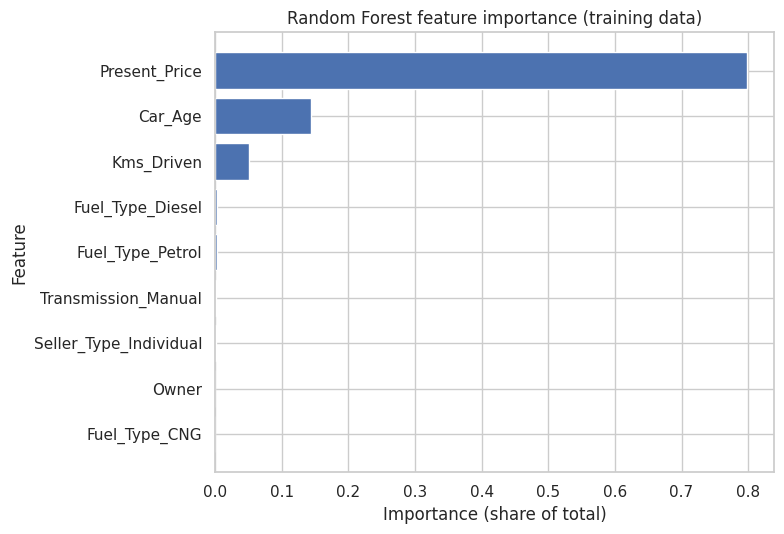

,Random Forest,Final Gradient Boosting
Car_Age,0.144,0.196
Fuel_Type_CNG,0.000,0.000
Fuel_Type_Diesel,0.002,0.012
Fuel_Type_Petrol,0.002,0.007
Kms_Driven,0.051,0.029
Owner,0.000,0.000
Present_Price,0.799,0.755
Seller_Type_Individual,0.000,0.000
Transmission_Manual,0.001,0.001


In [37]:
rf_importance = get_importances(pipelines["Random Forest"])
gb_importance = get_importances(final_pipeline)
rf_importance.to_csv(RESULTS_DIR / "feature_importance_random_forest.csv", header=["importance"])

plot_feature_importance(rf_importance, "Random Forest feature importance (training data)")
plt.show()

pd.DataFrame({"Random Forest": rf_importance, "Final Gradient Boosting": gb_importance}).round(3)

**Interpretation.** `Present_Price` dominates (about 0.80 of total importance in the Random Forest) - matching its strong 0.82 correlation with the target. `Car_Age` (0.14) and `Kms_Driven` (0.05) follow, and the one-hot encoded categorical columns each contribute very little individually. This matches intuition: a car's resale value is anchored mainly to what it costs new, adjusted for age and usage. Importance shows what the model *relies on*, not proof of what *causes* price.

## 17. Actual vs Predicted and Residual Analysis

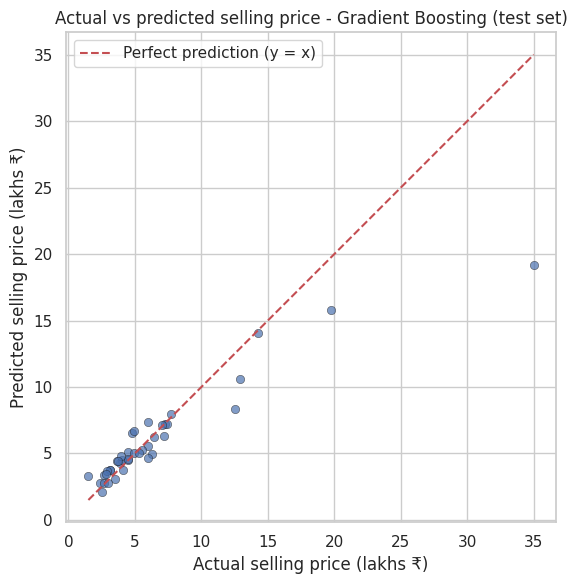

In [38]:
plot_actual_vs_predicted(y_test, test_pred,
                         f"Actual vs predicted selling price - {best_name} (test set)")
plt.show()

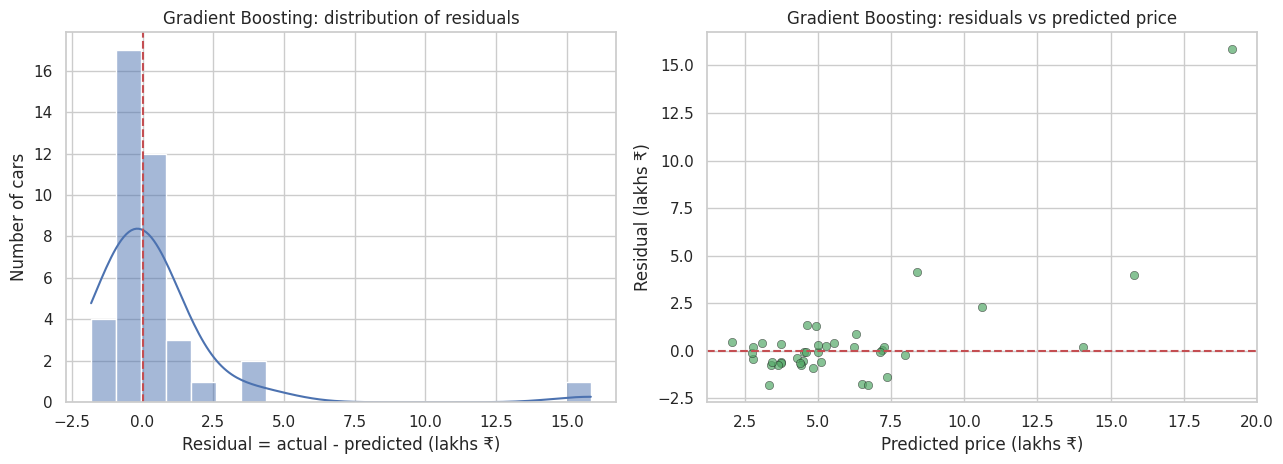

Mean residual : 0.449
Std residual  : 2.753
Largest miss  : -1.82 to 15.85


In [39]:
_, residuals = plot_residuals(y_test, test_pred, best_name)
plt.show()

print("Mean residual :", round(residuals.mean(), 3))
print("Std residual  :", round(residuals.std(), 3))
print("Largest miss  :", round(residuals.min(), 2), "to", round(residuals.max(), 2))

In [40]:
# Investigate the largest miss
errors = pd.DataFrame({"actual": y_test.values, "predicted": test_pred.round(2)}, index=X_test.index)
errors["abs_error"] = (errors["actual"] - errors["predicted"]).abs().round(2)
errors = errors.join(X_test[["Present_Price", "Car_Age", "Kms_Driven"]])
worst = errors.sort_values("abs_error", ascending=False)
worst.head(5)

,actual,predicted,abs_error,Present_Price,Car_Age,Kms_Driven
85,35.00,19.15,15.85,92.60,8,78000
82,12.50,8.37,4.13,13.46,3,38000
65,19.75,15.79,3.96,23.15,1,11000
147,12.90,10.59,2.31,13.60,2,35934
76,1.50,3.32,1.82,12.35,14,135154


In [41]:
worst_idx = worst.index[0]
rmse_all = np.sqrt((errors["actual"] - errors["predicted"]).pow(2).mean())
rmse_excl = np.sqrt(((errors["actual"] - errors["predicted"]) ** 2).drop(worst_idx).mean())
print(f"Test RMSE including the single largest miss: {rmse_all:.3f}")
print(f"Test RMSE excluding that one car            : {rmse_excl:.3f}")

Test RMSE including the single largest miss: 2.789
Test RMSE excluding that one car            : 1.240


**Interpretation.** The single largest miss is a **Land Cruiser** (Present_Price ₹92.6L, actual Selling_Price ₹35L) that the model predicted at about ₹19L. This is a genuine, correctly recorded car - not a data error - but it is the most expensive car in the whole dataset by a wide margin, and models trained on mostly ₹3-15L cars have very little to learn from about that price bracket. Excluding this single point, test RMSE falls from about 2.79 to about 1.24, close to the cross-validated estimate (1.14-1.16). This is an honest limitation, not a hidden one: with only 198 rows, one rare high-value car can dominate a 40-row test set's RMSE. MAE (1.19), which is less sensitive to a single large error, is a fairer everyday summary of this model's accuracy than RMSE alone.

The residual plot otherwise shows no strong systematic pattern (no obvious curve or funnel), aside from this one high-leverage point.

## 18. Sample Predictions

In [42]:
# (a) A real car from the held-out test set, compared with its actual price
sample = X_test.iloc[1].to_dict()
print("Input features:", sample)
print("\nPredicted selling price:", format_price(predict_price(sample)))
print("Actual selling price   :", format_price(float(y_test.iloc[1])))

Input features: {'Present_Price': 4.43, 'Kms_Driven': 15000, 'Car_Age': 2, 'Owner': 0, 'Fuel_Type': 'Petrol', 'Seller_Type': 'Dealer', 'Transmission': 'Manual'}

Predicted selling price: ₹374,718  (3.75 lakhs)
Actual selling price   : ₹315,000  (3.15 lakhs)


In [43]:
# (b) A hypothetical car typed in by hand
new_car = {"Present_Price": 8.5, "Kms_Driven": 35000, "Car_Age": 4, "Owner": 0,
           "Fuel_Type": "Petrol", "Seller_Type": "Dealer", "Transmission": "Manual"}
print("Predicted selling price:", format_price(predict_price(new_car)))

Predicted selling price: ₹578,427  (5.78 lakhs)


Case (a) is a real held-out car (its predicted and actual prices can be compared directly). Case (b) is a hypothetical car with no ground truth - it only demonstrates the mechanics. The same `predict_price()` function powers the command-line tool (`src/predict.py`) and the Streamlit app (`streamlit run app.py`).

## 19. Conclusion

* The supplied `car.csv` (301 rows) was found to mix **200 cars with 101 two-wheelers**; the two-wheelers were excluded so the project genuinely predicts *car* prices as asked, leaving 198 cars after removing 2 duplicate rows.
* Four regression models were compared by 5-fold cross-validation on the training data. **Gradient Boosting** was selected (CV RMSE 1.16, tuned to 1.14) and, after tuning, reached a test MAE of **1.19 lakh** and test R² of **0.77**.
* A single very expensive, rarely-represented car (a Land Cruiser) accounts for most of the gap between the cross-validated R² (0.94) and the test R² (0.77) - excluding it, test RMSE nearly matches the cross-validated estimate.
* **`Present_Price`** (the current showroom price) is by far the strongest driver of predicted resale price, followed by **`Car_Age`**.
* A log-transformed target was tested and found to help the weaker linear/tree models but not the selected Gradient Boosting model, so the final model uses the raw target - a decision made from measured results, not assumption.

## 20. Future Scope

* Collect more high-value cars so the model has enough examples across the full price range.
* Test log-target Gradient Boosting with a wider hyper-parameter search (the raw-vs-log gap for GB was small and could shift).
* Try XGBoost/LightGBM and simple stacking.
* Extract brand from `Car_Name` (as a lower-cardinality feature than the full model name) and test whether it adds predictive value beyond `Present_Price`.
* Use SHAP values for per-prediction explanations in the Streamlit app.
* Collect a larger, more current dataset (this one covers cars from 2003-2018) and revisit CNG and Individual-seller pricing once more examples are available.